In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error
from scipy.optimize import curve_fit


In [31]:
df= pd.read_csv('resource_pressure_data_main.csv')

In [32]:
df = df[df['cpu_avg'] > 0].copy()
df['failure_rate'] = df['request_failed_count'] / df['request_sent_count']
column_name='pod_count'
df['resource_pressure'] = df['cpu_avg'] / (df[column_name] * 2)  # 2 vCPUs per node

In [33]:
df

,pod_count,request_sent_count,request_failed_count,cpu_avg,memory_avg,user_count,request_interval,test_duration,failure_rate,resource_pressure
0,1,4,1,95.828571,132.992167,1,15,60,0.250000,47.914286
1,1,8,8,125.566667,134.317430,2,15,60,1.000000,62.783333
2,1,12,12,95.164251,133.440621,3,15,60,1.000000,47.582125
3,1,16,16,94.423810,133.840192,4,15,60,1.000000,47.211905
4,1,20,20,94.018255,134.185628,5,15,60,1.000000,47.009127
5,1,24,24,93.727381,134.356587,6,15,60,1.000000,46.863690
6,1,28,28,93.202381,134.430943,7,15,60,1.000000,46.601190
7,1,32,32,93.220238,133.996160,8,15,60,1.000000,46.610119
8,1,36,36,93.673810,131.166072,9,15,60,1.000000,46.836905
9,1,40,40,128.404762,132.459761,10,15,60,1.000000,64.202381


In [34]:
X = df[["resource_pressure"]]
y = df["failure_rate"]
X,y

(    resource_pressure
 0           47.914286
 1           62.783333
 2           47.582125
 3           47.211905
 4           47.009127
 5           46.863690
 6           46.601190
 7           46.610119
 8           46.836905
 9           64.202381
 10          49.500000
 12          22.734524
 13          26.197321
 14          31.401233
 15          36.154762
 16          35.910119
 17          35.297251
 18          34.964037
 19          35.285258
 20          35.209524
 21          24.015476
 22          19.009524
 23          19.914683
 24          30.131746
 25          24.800888
 26          26.514508
 27          32.239484
 28          32.094048
 29          32.063492
 30          32.122024
 31          32.107937
 32          27.852438
 33          18.393155
 34          18.479286
 35          26.033640
 36          27.645952
 37          24.883810
 38          21.145248
 39          21.623810
 40          20.981190
 41          24.103810
 42          27.295714
 43        

degree=1, rmse=0.36843395707972604
degree=2, rmse=0.3700403600269825
degree=3, rmse=0.3808288674099627
degree=4, rmse=0.3471416087186615
degree=5, rmse=0.34213667781981155
degree=6, rmse=0.33934666957019904
degree=7, rmse=0.33935620316175746


/Users/anirudhkaluri/.local/share/virtualenvs/ALDA_HW3-J51nOk3J/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


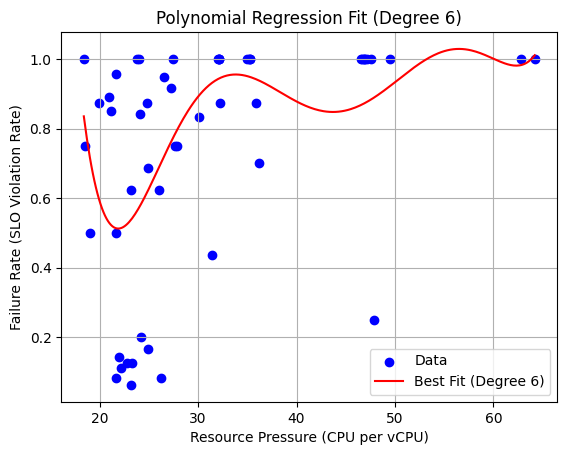

In [41]:
best_degree = None
best_score = -np.inf
best_model = None
best_rmse = float('inf')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
for degree in [1, 2, 3, 4 ,5, 6, 7]:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred=model.predict(X_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    print(f"degree={degree}, rmse={rmse_test}")

    
    if rmse_test< best_rmse:
        best_rmse = rmse_test
        best_model = model
        best_degree = degree

# Plot best fit
plt.scatter(X, y, label="Data", color='blue')
x_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_range_pred = best_model.predict(x_range)
plt.plot(x_range, y_range_pred, color='red', label=f"Best Fit (Degree {best_degree})")
plt.xlabel("Resource Pressure (CPU per vCPU)")
plt.ylabel("Failure Rate (SLO Violation Rate)")
plt.title(f"Polynomial Regression Fit (Degree {best_degree})")
plt.legend()
plt.grid(True)
plt.show()


Sigmoid Fit: RMSE = 0.3731


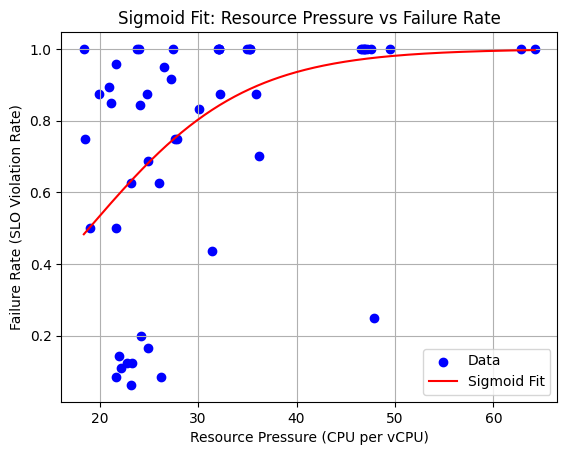

In [46]:
#sigmoid
def sigmoid(x, a, b):
    return 1 / (1 + np.exp(-a * (x - b)))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit sigmoid to training data (flattened)
popt, _ = curve_fit(sigmoid, X_train.values.ravel(), y_train, p0=[0.1, np.mean(X_train.values)])

# Predict (flatten inputs)
y_train_pred = sigmoid(X_train.values.ravel(), *popt)
y_test_pred = sigmoid(X_test.values.ravel(), *popt)


# Evaluate
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
print(f"Sigmoid Fit: RMSE = {rmse_test:.4f}")

# Plot best sigmoid fit
plt.scatter(X, y, label="Data", color='blue')
x_range = np.linspace(X.min(), X.max(), 300)
y_range_pred = sigmoid(x_range, *popt)
plt.plot(x_range, y_range_pred, color='red', label="Sigmoid Fit")
plt.xlabel("Resource Pressure (CPU per vCPU)")
plt.ylabel("Failure Rate (SLO Violation Rate)")
plt.title("Sigmoid Fit: Resource Pressure vs Failure Rate")
plt.legend()
plt.grid(True)
plt.show()